In [30]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


The dataset contains passenger details from the Titanic disaster.
It includes features like age, gender, class, fare, and survival status.
The target variable is 'Survived'.
Some columns contain missing values such as Age and Cabin.
This dataset is used for classification tasks.

In [31]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop irrelevant columns
df = df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, errors='ignore')

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

Missing values in Age were filled using median.
Embarked missing values were filled using mode.
Columns like Name, Ticket, and Cabin were removed as they are not useful.
Categorical features like Sex and Embarked were encoded.

In [32]:
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was split into training and testing sets.
80% data was used for training and 20% for testing.
This ensures proper model evaluation.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

Three models were trained: Logistic Regression, Random Forest, and KNN.
Each model learns patterns differently.
This helps compare performance and select the best model.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate(y_test, y_pred):
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [
        evaluate(y_test, y_pred_lr)[0],
        evaluate(y_test, y_pred_rf)[0],
        evaluate(y_test, y_pred_knn)[0]
    ],
    'Precision': [
        evaluate(y_test, y_pred_lr)[1],
        evaluate(y_test, y_pred_rf)[1],
        evaluate(y_test, y_pred_knn)[1]
    ],
    'Recall': [
        evaluate(y_test, y_pred_lr)[2],
        evaluate(y_test, y_pred_rf)[2],
        evaluate(y_test, y_pred_knn)[2]
    ],
    'F1 Score': [
        evaluate(y_test, y_pred_lr)[3],
        evaluate(y_test, y_pred_rf)[3],
        evaluate(y_test, y_pred_knn)[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Random Forest,0.810056,0.777778,0.756757,0.767123
2,KNN,0.703911,0.684211,0.527027,0.595420


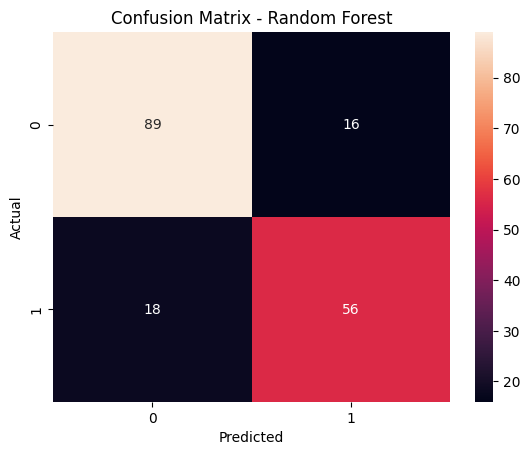

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

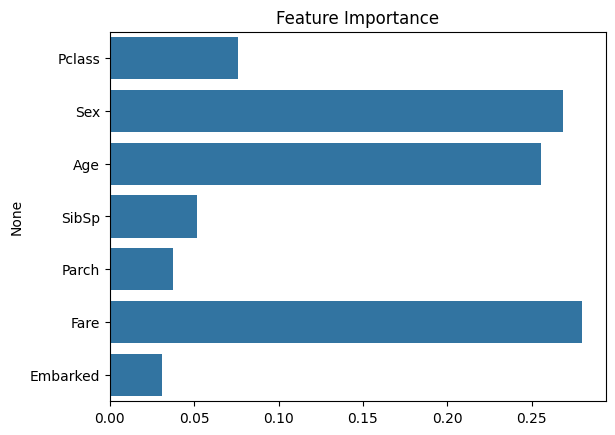

In [36]:
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()

Three machine learning models were trained and compared.
Random Forest performed the best among all models.
It provided better accuracy and handled feature interactions effectively.
Proper preprocessing improved model performance.
This project shows the importance of model comparison in ML.